# AI Equity Research & Portfolio Intelligence Tool


---

## How to run this notebook

1. Install packages: run the first code cell once (`pip install -r requirements.txt`) or let the `%pip install` cell handle it.
2. Open **Section 3 — USER INPUTS** and set your tickers, benchmark, and dates.
3. Choose **Kernel → Restart & Run All**.
4. Read the Final Dashboard at the bottom for the executive summary.

> **Important:** this is a research tool, not investment advice. Historical performance does not guarantee future results.

---

## What this tool does

This notebook builds a complete, employer-ready investment research workflow by integrating six analytical modules:

| Module | Techniques |
|--------|-----------|
| S2 — Market Data | Adjusted prices, returns, data-quality checks, time-varying risk-free rate |
| S3 — Risk Analytics | Sharpe, Sortino, Calmar, VaR (3 methods), CVaR, Max Drawdown, stress tests |
| S4 — Factor Models | CAPM, Fama-French 3-Factor, Carhart 4-Factor (momentum), rolling beta |
| S4 — NLP | Loughran-McDonald sentiment, VADER sentiment, TF-IDF keyword extraction |
| S5 — Optimisation | Equal Weight, Max Sharpe, Min Volatility, Black-Litterman |
| S6 — Signals & Backtesting | Market-timing momentum, cross-sectional momentum, OOS validation, transaction costs |

All sections update automatically when you change the USER INPUTS cell.

## Data sources
- **Yahoo Finance** (yfinance) — adjusted daily closing prices
- **FRED** (Federal Reserve) — 3-month Treasury Bill rate (TB3MS)
- **Kenneth French Data Library** — Fama-French / Carhart daily factors
- **SEC EDGAR** — company Form 10-K filings


# 1. Setup / Install Packages

Run this cell once if your computer is missing packages. If everything is already installed, you can skip it.

# 2. Imports

This section imports Python libraries used throughout the project. It avoids `pandas_datareader` because it can have compatibility issues with newer Python versions.

In [30]:
import os
import re
import io
import zipfile
import warnings
from datetime import datetime

%pip install yfinance==0.2.55 pandas numpy matplotlib scipy statsmodels scikit-learn vaderSentiment requests beautifulsoup4 seaborn

import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

import yfinance as yf
import matplotlib.pyplot as plt
import requests
import statsmodels.api as sm

from scipy import stats
from scipy.optimize import minimize
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


# 3. USER INPUTS

Change only this section if you want to analyze a different portfolio or company.

In [31]:
##############################################################
# USER INPUTS — EDIT THESE IF NEEDED
##############################################################

PROJECT_NAME = "AI Equity Research and Portfolio Intelligence Tool"

# Choose 5 liquid U.S. stocks. Ideally use different sectors.
TICKERS = ["AAPL", "MSFT", "JPM", "XOM", "COST"]

# Benchmark used for CAPM, rolling beta, and momentum strategy.
BENCHMARK = "SPY"

# Main company used for SEC 10-K text analysis.
MAIN_TICKER = "AAPL"

# Analysis period.
START_DATE = "2021-05-01"
END_DATE = "2026-04-30"

# Out-of-sample split date.
SPLIT_DATE = "2024-01-01"

# Risk-free rate series from FRED. TB3MS = 3-month Treasury Bill rate.
RISK_FREE_SERIES = "TB3MS"

# Transaction cost assumption for the out-of-sample portfolio test.
TRANSACTION_COST_BPS = 10

# SEC requires a real user-agent. Replace with your own name/email if desired.
SEC_USER_AGENT = "Jasleen Majathia me@jasleen.ca"

# Output folder.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project:", PROJECT_NAME)
print("Portfolio tickers:", TICKERS)
print("Benchmark:", BENCHMARK)
print("Main SEC filing ticker:", MAIN_TICKER)

Project: AI Equity Research and Portfolio Intelligence Tool
Portfolio tickers: ['AAPL', 'MSFT', 'JPM', 'XOM', 'COST']
Benchmark: SPY
Main SEC filing ticker: AAPL


# 4. Helper Functions

These functions are reused throughout the notebook. They handle data downloads, risk metrics, regressions, optimization, SEC downloads, and text analysis.

In [32]:
##############################################################
# DATA DOWNLOAD FUNCTIONS
##############################################################

def download_prices(tickers, start, end):
    """Download split/dividend-adjusted close prices from Yahoo Finance.
    Returns a DataFrame with one column per ticker, indexed by date.
    """
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)["Close"]
    if isinstance(data, pd.Series):
        data = data.to_frame()
    return data.dropna(how="all")


def get_fred_series(series_id, start, end):
    """Download a monthly FRED series via the public CSV endpoint.
    Avoids pandas_datareader (Python 3.13 incompatible).
    Returns a DataFrame indexed by date, forward-filled to handle weekends.
    """
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    df.columns = ["DATE", series_id]
    df["DATE"] = pd.to_datetime(df["DATE"])
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    df = df.set_index("DATE").sort_index()
    return df.loc[start:end].ffill()


def get_fama_french_daily_factors():
    """Download Fama-French 3-factor daily data from the French Data Library.
    Returns decimal (not percentage) returns indexed by date.
    Factors: Mkt-RF (market excess return), SMB (size), HML (value), RF (risk-free).
    """
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(response.content))
    raw = z.read(z.namelist()[0]).decode("utf-8")
    data_lines = [l for l in raw.splitlines() if re.match(r"^\d{8},", l)]
    ff = pd.read_csv(io.StringIO("\n".join(data_lines)), header=None)
    ff.columns = ["Date", "Mkt-RF", "SMB", "HML", "RF"]
    ff["Date"] = pd.to_datetime(ff["Date"].astype(str), format="%Y%m%d")
    ff = ff.set_index("Date").sort_index()
    return ff / 100


def get_carhart_daily_factors():
    """Download Fama-French + Momentum (Carhart 4-factor) daily data.
    Adds UMD (Up-Minus-Down momentum factor) to the FF3 factors.
    Source: Kenneth French Data Library — Momentum Factor (Daily).
    """
    # Download FF3 first
    ff3 = get_fama_french_daily_factors()

    # Download UMD (momentum) factor
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip"
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(response.content))
        raw = z.read(z.namelist()[0]).decode("utf-8")
        data_lines = [l for l in raw.splitlines() if re.match(r"^\d{8},", l)]
        umd = pd.read_csv(io.StringIO("\n".join(data_lines)), header=None)
        umd.columns = ["Date", "UMD"]
        umd["Date"] = pd.to_datetime(umd["Date"].astype(str), format="%Y%m%d")
        umd = umd.set_index("Date").sort_index() / 100
        ff4 = ff3.join(umd, how="inner")
        return ff4
    except Exception as e:
        print(f"Warning: UMD download failed ({e}). Returning FF3 without UMD.")
        ff3["UMD"] = np.nan
        return ff3

##############################################################
# RISK METRIC FUNCTIONS
##############################################################

def annualized_return(r):
    """Compound annualized return over the full period (252 trading days/year)."""
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    return (1 + r).prod() ** (252 / len(r)) - 1


def annualized_volatility(r):
    """Annualized standard deviation of daily returns (252 trading days/year)."""
    r = r.dropna()
    return r.std() * np.sqrt(252)


def sharpe_ratio(r, rf):
    """Annualized Sharpe Ratio: mean excess return / std of excess returns.
    Uses daily excess returns relative to a time-varying risk-free rate.
    """
    r = r.dropna()
    rf = rf.reindex(r.index).ffill().dropna()
    common = r.index.intersection(rf.index)
    excess = r.loc[common] - rf.loc[common]
    if len(excess) == 0 or excess.std() == 0:
        return np.nan
    return excess.mean() / excess.std() * np.sqrt(252)


def sortino_ratio(r, rf):
    """Annualized Sortino Ratio: penalises only downside (negative excess) volatility.
    Higher than Sharpe when most volatility comes from positive returns.
    """
    r = r.dropna()
    rf = rf.reindex(r.index).ffill().dropna()
    common = r.index.intersection(rf.index)
    excess = r.loc[common] - rf.loc[common]
    downside = excess[excess < 0]
    if len(downside) == 0 or downside.std() == 0:
        return np.nan
    return excess.mean() / downside.std() * np.sqrt(252)


def max_drawdown(r):
    """Maximum peak-to-trough decline in cumulative wealth.
    Returns (max_drawdown_value, full drawdown series).
    """
    r = r.dropna()
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min(), drawdown


def calmar_ratio(r):
    """Calmar Ratio: annualized return divided by absolute maximum drawdown.
    Higher values mean better return per unit of drawdown risk.
    """
    ann_ret = annualized_return(r)
    mdd, _ = max_drawdown(r)
    if mdd == 0 or pd.isna(mdd):
        return np.nan
    return ann_ret / abs(mdd)


def historical_var(r, confidence=0.95):
    """Historical (empirical) VaR at given confidence level.
    No distribution assumption — uses actual return percentile.
    """
    return np.percentile(r.dropna(), (1 - confidence) * 100)


def parametric_var(r, confidence=0.95):
    """Parametric (Gaussian) VaR: assumes normally distributed returns.
    Most conservative when returns are fat-tailed.
    """
    r = r.dropna()
    mu = r.mean()
    sigma = r.std()
    z = stats.norm.ppf(1 - confidence)
    return mu + z * sigma


def monte_carlo_var(r, confidence=0.95, sims=10000, seed=42):
    """Monte Carlo VaR: simulates returns from fitted normal distribution.
    Seed fixed for reproducibility.
    """
    r = r.dropna()
    rng = np.random.default_rng(seed)
    simulated = rng.normal(r.mean(), r.std(), sims)
    return np.percentile(simulated, (1 - confidence) * 100)


def cvar(r, confidence=0.95):
    """Conditional VaR (Expected Shortfall): mean of returns below VaR threshold.
    More informative than VaR because it measures the severity of tail losses.
    """
    r = r.dropna()
    var = historical_var(r, confidence)
    return r[r <= var].mean()

##############################################################
# REGRESSION FUNCTIONS
##############################################################

def run_capm(asset_returns, market_returns, rf_daily):
    """OLS CAPM regression: asset excess return ~ alpha + beta * market excess return.
    Alpha is Jensen's alpha (daily); multiply by 252 for annualized alpha.
    """
    df = pd.concat([asset_returns, market_returns, rf_daily], axis=1).dropna()
    df.columns = ["asset", "market", "rf"]
    df["asset_excess"] = df["asset"] - df["rf"]
    df["market_excess"] = df["market"] - df["rf"]
    X = sm.add_constant(df["market_excess"])
    y = df["asset_excess"]
    return sm.OLS(y, X).fit()


def run_ff3(asset_returns, ff_factors):
    """Fama-French 3-Factor OLS regression.
    Factors: Mkt-RF (market), SMB (size: small-minus-big), HML (value: high-minus-low book).
    Negative HML = growth tilt; positive = value tilt.
    """
    df = pd.concat([asset_returns, ff_factors], axis=1).dropna()
    df.columns = ["asset"] + list(ff_factors.columns)
    y = df["asset"] - df["RF"]
    X = sm.add_constant(df[["Mkt-RF", "SMB", "HML"]])
    return sm.OLS(y, X).fit()


def run_ff4(asset_returns, ff4_factors):
    """Carhart 4-Factor OLS regression (FF3 + UMD momentum factor).
    UMD = Up-Minus-Down: positive loading = momentum tilt (recent winners tend to outperform).
    Adding UMD separates factor alpha from momentum-driven returns.
    """
    df = pd.concat([asset_returns, ff4_factors], axis=1).dropna()
    df = df.dropna()
    cols = ["asset"] + list(ff4_factors.columns)
    df.columns = cols
    y = df["asset"] - df["RF"]
    X = sm.add_constant(df[["Mkt-RF", "SMB", "HML", "UMD"]])
    return sm.OLS(y, X).fit()


def rolling_beta(asset_returns, market_returns, window=126):
    """Rolling 126-day beta (approx. 6 months). Shows how systematic risk evolves over time."""
    cov = asset_returns.rolling(window).cov(market_returns)
    var = market_returns.rolling(window).var()
    return cov / var

##############################################################
# OPTIMIZATION FUNCTIONS
##############################################################

def portfolio_performance(weights, mu, cov, rf_rate):
    """Compute expected return, volatility, and Sharpe for a given weight vector."""
    port_return = float(np.dot(weights, mu))
    port_vol = float(np.sqrt(weights.T @ cov @ weights))
    sharpe = (port_return - rf_rate) / port_vol if port_vol != 0 else np.nan
    return port_return, port_vol, sharpe


def negative_sharpe(weights, mu, cov, rf_rate):
    return -portfolio_performance(weights, mu, cov, rf_rate)[2]


def portfolio_volatility(weights, cov):
    return float(np.sqrt(weights.T @ cov @ weights))


def optimize_max_sharpe(mu, cov, rf_rate):
    """Maximise Sharpe Ratio subject to full investment and no short-selling.
    Uses SLSQP (Sequential Least Squares Programming) from scipy.
    """
    n = len(mu)
    init = np.repeat(1 / n, n)
    bounds = tuple((0, 1) for _ in range(n))
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    result = minimize(negative_sharpe, init, args=(mu, cov, rf_rate),
                      method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        print("Warning: Max Sharpe optimisation did not converge:", result.message)
    return result.x


def optimize_min_vol(cov):
    """Minimise portfolio volatility (Global Minimum Variance portfolio)."""
    n = cov.shape[0]
    init = np.repeat(1 / n, n)
    bounds = tuple((0, 1) for _ in range(n))
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    result = minimize(portfolio_volatility, init, args=(cov,),
                      method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        print("Warning: Min Vol optimisation did not converge:", result.message)
    return result.x


def get_market_caps(tickers):
    """Fetch market capitalisation from yfinance. Falls back to equal weighting if data missing."""
    caps = {}
    for ticker in tickers:
        try:
            caps[ticker] = yf.Ticker(ticker).info.get("marketCap", np.nan)
        except Exception:
            caps[ticker] = np.nan
    caps_series = pd.Series(caps, dtype="float")
    if caps_series.isna().any() and caps_series.notna().sum() > 0:
        caps_series = caps_series.fillna(caps_series.dropna().mean())
    if caps_series.isna().any():
        caps_series = pd.Series(1.0, index=tickers)
    return caps_series

##############################################################
# EFFICIENT FRONTIER HELPER
##############################################################

def compute_efficient_frontier(mu, cov, rf_rate, n_points=300):
    """Simulate random portfolios to trace the efficient frontier.
    Returns DataFrame with Return, Volatility, Sharpe for each simulated portfolio.
    """
    np.random.seed(42)
    n = len(mu)
    results = []
    for _ in range(n_points * 10):
        w = np.random.dirichlet(np.ones(n))
        r, v, s = portfolio_performance(w, mu, cov, rf_rate)
        results.append({"Return": r, "Volatility": v, "Sharpe": s})
    return pd.DataFrame(results)

##############################################################
# SEC / TEXT FUNCTIONS
##############################################################

HEADERS = {"User-Agent": SEC_USER_AGENT}


def get_cik(ticker):
    url = "https://www.sec.gov/files/company_tickers.json"
    data = requests.get(url, headers=HEADERS, timeout=30).json()
    for item in data.values():
        if item["ticker"].upper() == ticker.upper():
            return str(item["cik_str"]).zfill(10)
    raise ValueError(f"Ticker {ticker} not found in SEC ticker list.")


def get_latest_10k_url(ticker):
    cik = get_cik(ticker)
    submissions_url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    submissions = requests.get(submissions_url, headers=HEADERS, timeout=30).json()
    forms = submissions["filings"]["recent"]["form"]
    accession_numbers = submissions["filings"]["recent"]["accessionNumber"]
    primary_docs = submissions["filings"]["recent"]["primaryDocument"]
    for form, accession, doc in zip(forms, accession_numbers, primary_docs):
        if form == "10-K":
            accession_clean = accession.replace("-", "")
            return f"https://www.sec.gov/Archives/edgar/data/{int(cik)}/{accession_clean}/{doc}"
    raise ValueError(f"No recent 10-K found for {ticker}.")


def get_filing_text(ticker):
    url = get_latest_10k_url(ticker)
    html = requests.get(url, headers=HEADERS, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")
    text = soup.get_text(separator=" ")
    text = re.sub(r"\s+", " ", text)
    return text, url


def extract_risk_snippets(text, keywords=None, window=300):
    if keywords is None:
        keywords = ["risk", "uncertain", "inflation", "interest rate", "competition",
                    "supply", "regulation", "cybersecurity"]
    snippets = []
    lower_text = text.lower()
    for keyword in keywords:
        match = re.search(keyword, lower_text)
        if match:
            start = max(match.start() - window, 0)
            end = min(match.end() + window, len(text))
            snippets.append({"Keyword": keyword, "Snippet": text[start:end]})
    return pd.DataFrame(snippets)


def simple_lm_score(text):
    """Finance-specific sentiment using a simplified Loughran-McDonald word list.
    Polarity = (positive - negative) / (positive + negative). Negative is normal for 10-Ks.
    """
    lm_negative_words = [
        "adverse", "decline", "decrease", "deteriorate", "loss", "risk", "uncertain",
        "impairment", "litigation", "weakness", "volatile", "challenge", "constraint",
        "default", "fraud", "failure", "recession", "inflation", "shortage", "disruption"
    ]
    lm_positive_words = [
        "growth", "improve", "strong", "benefit", "profitable", "opportunity",
        "increase", "gain", "success", "efficient", "favorable", "advantage", "strength"
    ]
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    neg = sum(word in lm_negative_words for word in words)
    pos = sum(word in lm_positive_words for word in words)
    polarity = (pos - neg) / max(pos + neg, 1)
    return {"Positive Words": pos, "Negative Words": neg, "Total Words": len(words), "Polarity": polarity}


def chunk_text(text, max_chars=1500):
    sentences = re.split(r"(?<=[.!?]) +", text)
    chunks, current = [], ""
    for sentence in sentences:
        if len(current) + len(sentence) < max_chars:
            current += " " + sentence
        else:
            if current.strip():
                chunks.append(current.strip())
            current = sentence
    if current.strip():
        chunks.append(current.strip())
    return chunks


def top_tfidf_terms(text, n=20):
    chunks = chunk_text(text[:80000], max_chars=1500)
    if len(chunks) < 2:
        return pd.DataFrame({"Term": [], "TF-IDF Score": []})
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000, ngram_range=(1, 2))
    X = vectorizer.fit_transform(chunks)
    scores = np.asarray(X.mean(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    top_idx = scores.argsort()[-n:][::-1]
    return pd.DataFrame({"Term": terms[top_idx], "TF-IDF Score": scores[top_idx]})

print("Helper functions loaded successfully.")


Helper functions loaded successfully.


# 5. Download Market Data

This section downloads adjusted close prices, computes stock returns, benchmark returns, and the equal-weighted portfolio return.

Price data shape: (1254, 6)


Ticker,AAPL,COST,JPM,MSFT,SPY,XOM
Date,,,,,,
2026-04-23,273.1783,"1,012.9102",311.6900,414.8515,706.6296,149.5152
2026-04-24,270.8105,"1,009.6849",308.2800,423.7023,712.1055,147.9061
2026-04-27,267.3636,996.5640,311.6300,423.9019,713.3323,147.1909
2026-04-28,270.4608,992.5598,311.4500,428.3223,709.8612,149.5450
2026-04-29,269.9213,997.2230,309.2500,423.5426,709.7515,153.6273


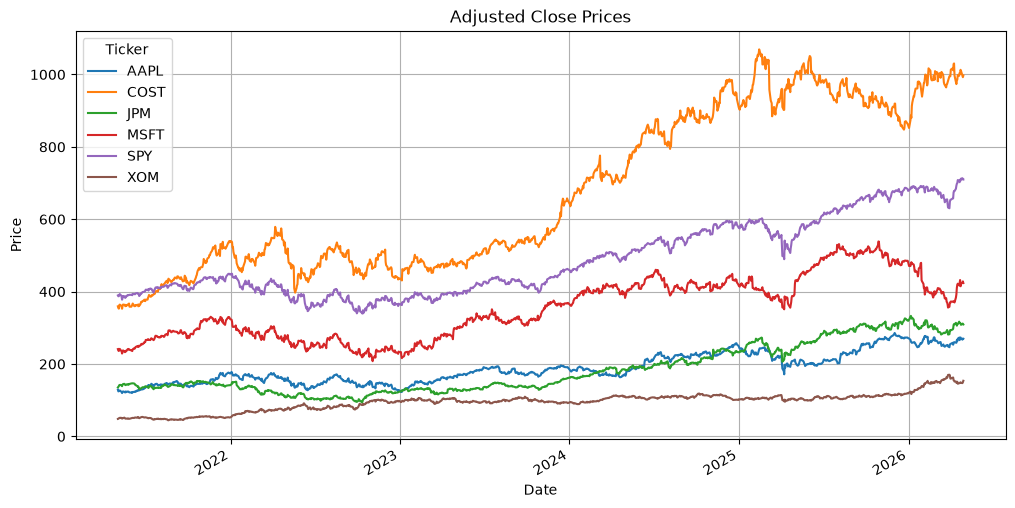

In [33]:
all_tickers = TICKERS + [BENCHMARK]
prices = download_prices(all_tickers, START_DATE, END_DATE)

asset_prices = prices[TICKERS].dropna()
benchmark_prices = prices[BENCHMARK].dropna()

returns = asset_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()
portfolio_returns = returns.mean(axis=1)

print("Price data shape:", prices.shape)
display(prices.tail())

prices.plot(title="Adjusted Close Prices")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# 6. Download Risk-Free Rate from FRED

The project uses the 3-month Treasury Bill rate (`TB3MS`) from FRED. It is converted from an annual percentage rate to a daily decimal rate.

Risk-free data:


,TB3MS
DATE,
2025-12-01,3.5900
2026-01-01,3.5700
2026-02-01,3.6000
2026-03-01,3.6100
2026-04-01,3.6100


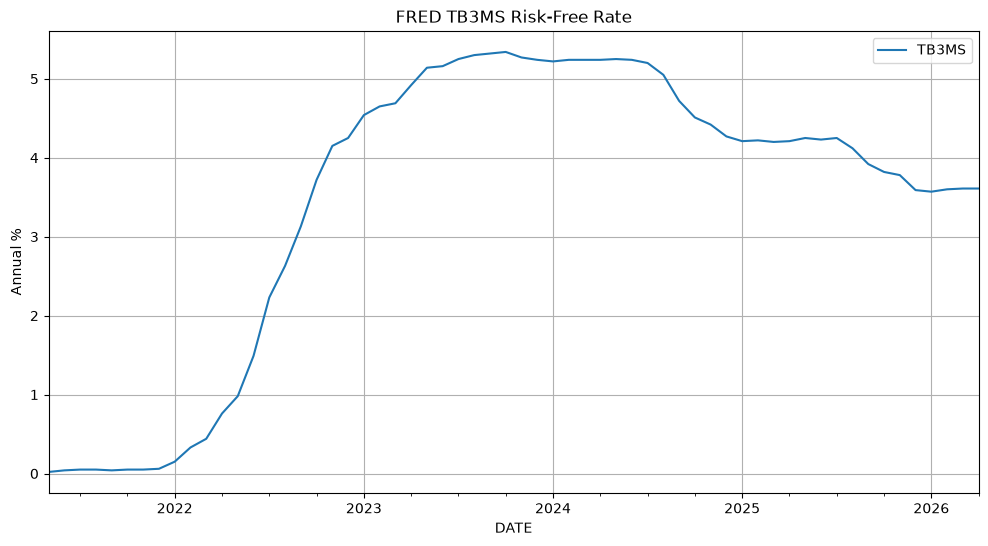

In [34]:
rf_monthly = get_fred_series(RISK_FREE_SERIES, START_DATE, END_DATE)
rf_daily = (rf_monthly[RISK_FREE_SERIES] / 100) / 252
rf_daily = rf_daily.reindex(portfolio_returns.index).ffill()

print("Risk-free data:")
display(rf_monthly.tail())

rf_monthly.plot(title="FRED TB3MS Risk-Free Rate")
plt.ylabel("Annual %")
plt.grid(True)
plt.show()

# 7. Data Quality Check

This section checks missing values and confirms that return data is available for all tickers.

In [35]:
data_quality = pd.DataFrame({
    "Missing Prices": asset_prices.isna().sum(),
    "First Date": asset_prices.apply(lambda x: x.first_valid_index()),
    "Last Date": asset_prices.apply(lambda x: x.last_valid_index()),
    "Return Observations": returns.count()
})

print("Data Quality Summary:")
display(data_quality)

Data Quality Summary:


,Missing Prices,First Date,Last Date,Return Observations
Ticker,,,,
AAPL,0,2021-05-03,2026-04-29,1253
MSFT,0,2021-05-03,2026-04-29,1253
JPM,0,2021-05-03,2026-04-29,1253
XOM,0,2021-05-03,2026-04-29,1253
COST,0,2021-05-03,2026-04-29,1253


# 8. Risk Analytics

This section creates a risk profile for the equal-weighted portfolio using the major downside and risk-adjusted metrics from the course.

,Equal-Weighted Portfolio
Annualized Return,0.2108
Annualized Volatility,0.1711
Sharpe Ratio,1.0125
Sortino Ratio,1.4068
Calmar Ratio,1.1827
Historical VaR 95%,-0.0161
Parametric VaR 95%,-0.0169
Monte Carlo VaR 95%,-0.0172
CVaR 95%,-0.0240
Max Drawdown,-0.1783


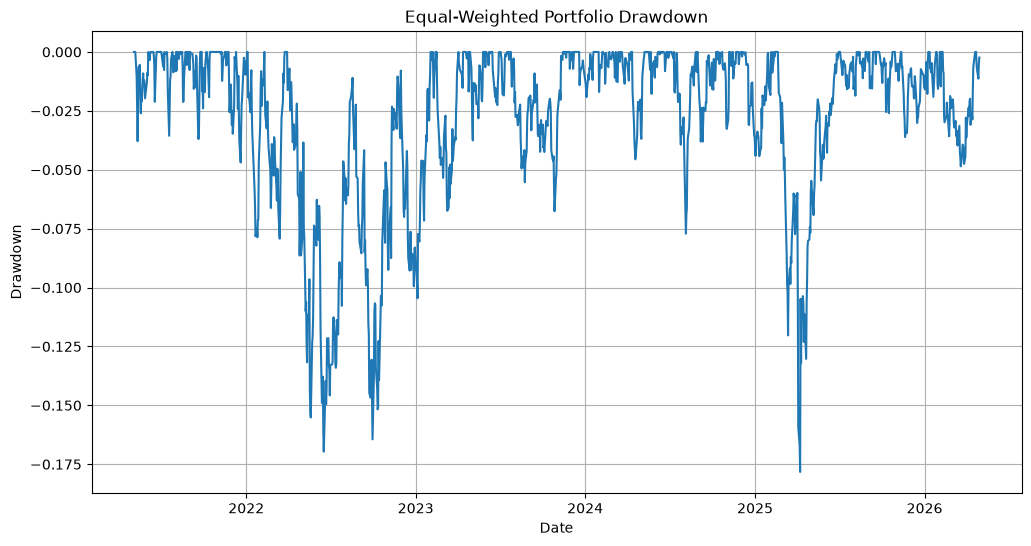

In [36]:
risk_summary = pd.DataFrame({
    "Annualized Return": [annualized_return(portfolio_returns)],
    "Annualized Volatility": [annualized_volatility(portfolio_returns)],
    "Sharpe Ratio": [sharpe_ratio(portfolio_returns, rf_daily)],
    "Sortino Ratio": [sortino_ratio(portfolio_returns, rf_daily)],
    "Calmar Ratio": [calmar_ratio(portfolio_returns)],
    "Historical VaR 95%": [historical_var(portfolio_returns)],
    "Parametric VaR 95%": [parametric_var(portfolio_returns)],
    "Monte Carlo VaR 95%": [monte_carlo_var(portfolio_returns)],
    "CVaR 95%": [cvar(portfolio_returns)],
    "Max Drawdown": [max_drawdown(portfolio_returns)[0]]
}).T
risk_summary.columns = ["Equal-Weighted Portfolio"]

display(risk_summary)

mdd, drawdown = max_drawdown(portfolio_returns)
plt.plot(drawdown)
plt.title("Equal-Weighted Portfolio Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True)
plt.show()

### VaR Method Comparison

Three VaR methods were computed. Comparing them reveals how much the choice of method affects the risk estimate —
an important consideration for risk managers who must choose a regulatory VaR model.


In [ ]:
# VaR comparison table — Historical vs Parametric vs Monte Carlo
var_comparison = pd.DataFrame({
    "Method": ["Historical (Empirical)", "Parametric (Gaussian)", "Monte Carlo (Simulated)"],
    "VaR 95% (Daily)": [
        historical_var(portfolio_returns),
        parametric_var(portfolio_returns),
        monte_carlo_var(portfolio_returns)
    ],
    "Assumption": [
        "No distribution assumed — uses actual return percentiles",
        "Returns are normally distributed — conservative if fat-tailed",
        "Returns simulated from fitted normal — similar to parametric"
    ]
})
display(var_comparison)
print(f"\nCVaR (Expected Shortfall) 95%: {cvar(portfolio_returns):.4f}")
print("CVaR = mean of returns below the VaR threshold — tells you HOW BAD the bad days are, not just how frequent.")
print("\nNote: If Parametric VaR is more negative than Historical VaR, returns have fat tails.")
print("In that case, Historical or Monte Carlo VaR is more reliable for risk management.")


# 9. Individual Stock Summary

This section compares risk and return across the individual stocks in the portfolio.

,Annualized Return,Annualized Volatility,Sharpe,Sortino,Calmar,Max Drawdown
AAPL,0.1601,0.2751,0.6015,0.8766,0.4800,-0.3336
MSFT,0.1199,0.2636,0.4392,0.6265,0.3229,-0.3715
JPM,0.1811,0.2436,0.6127,0.8543,0.4672,-0.3877
XOM,0.2623,0.2665,0.8844,1.2995,1.2792,-0.2051
COST,0.2279,0.2258,0.8821,1.1561,0.7256,-0.3140


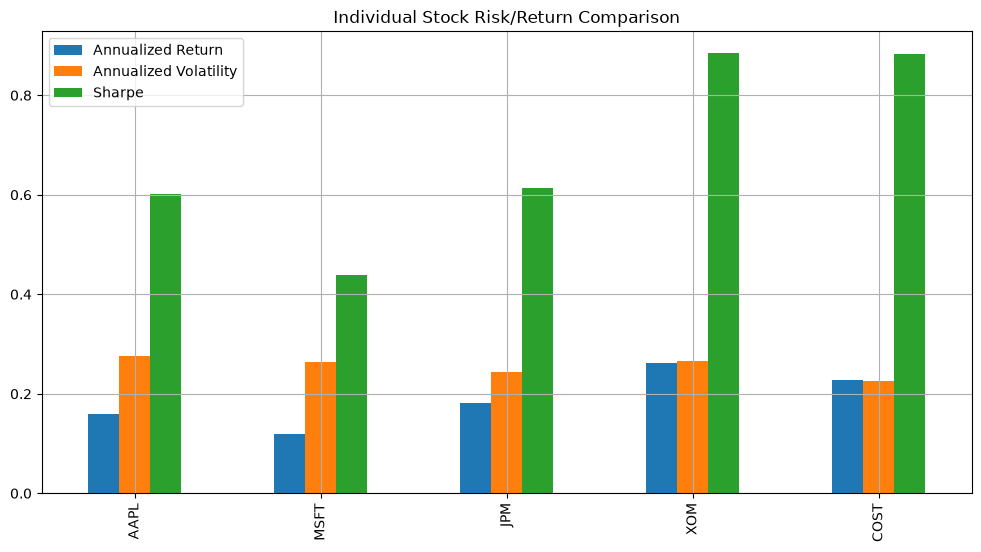

In [37]:
stock_summary = {}
for ticker in TICKERS:
    r = returns[ticker]
    stock_summary[ticker] = {
        "Annualized Return": annualized_return(r),
        "Annualized Volatility": annualized_volatility(r),
        "Sharpe": sharpe_ratio(r, rf_daily),
        "Sortino": sortino_ratio(r, rf_daily),
        "Calmar": calmar_ratio(r),
        "Max Drawdown": max_drawdown(r)[0]
    }
stock_summary_df = pd.DataFrame(stock_summary).T

display(stock_summary_df)

stock_summary_df[["Annualized Return", "Annualized Volatility", "Sharpe"]].plot(kind="bar")
plt.title("Individual Stock Risk/Return Comparison")
plt.grid(True)
plt.show()

# 9b. Correlation Heatmap

Pairwise return correlations show how stocks move together. Lower correlations mean better diversification.
Stocks with correlation near 1.0 provide little diversification benefit relative to each other.


In [ ]:
# Correlation heatmap
corr_matrix = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Pairwise Return Correlations")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
# Find the least correlated pair (best diversifier)
corr_vals = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
min_pair = corr_vals.stack().idxmin()
max_pair = corr_vals.stack().idxmax()
print(f"  Lowest correlation: {min_pair[0]} vs {min_pair[1]} ({corr_vals.stack().min():.2f}) — best diversification pair.")
print(f"  Highest correlation: {max_pair[0]} vs {max_pair[1]} ({corr_vals.stack().max():.2f}) — most similar return behaviour.")
print(f"  Average pairwise correlation: {corr_vals.stack().mean():.2f}")


# 10. Stress Period Analysis

User input: You can change `STRESS_START` and `STRESS_END`. The default is the 2022 rate-hike / market drawdown period.

,2022-01-01 to 2022-12-31
Stress Period Return,-0.0449
Stress Period Volatility,0.2515
Stress Period Max Drawdown,-0.1697


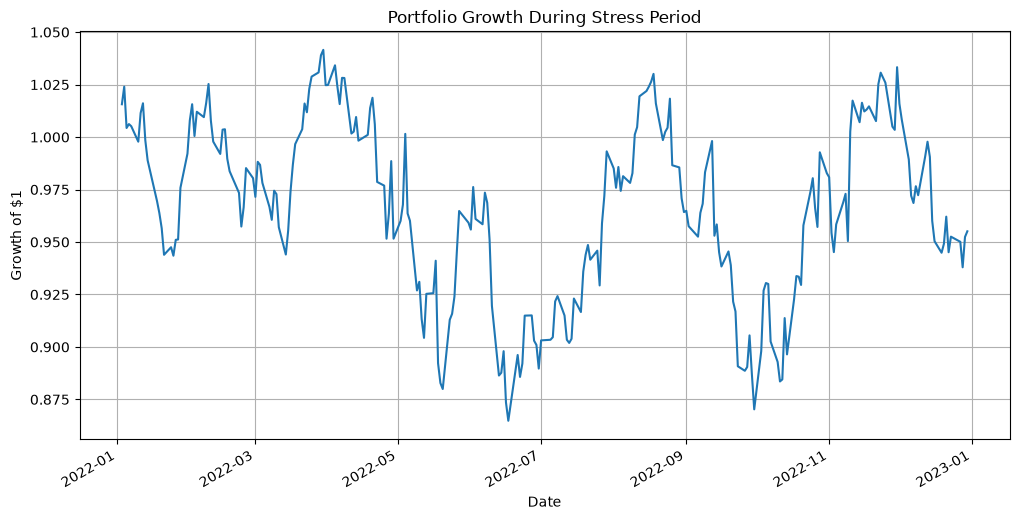

In [38]:
##############################################################
# USER INPUT — CHANGE STRESS PERIOD IF DESIRED
##############################################################
STRESS_START = "2022-01-01"
STRESS_END = "2022-12-31"

stress_returns = portfolio_returns.loc[STRESS_START:STRESS_END]
stress_summary = pd.DataFrame({
    "Stress Period Return": [(1 + stress_returns).prod() - 1],
    "Stress Period Volatility": [annualized_volatility(stress_returns)],
    "Stress Period Max Drawdown": [max_drawdown(stress_returns)[0]]
}).T
stress_summary.columns = [f"{STRESS_START} to {STRESS_END}"]

display(stress_summary)

(1 + stress_returns).cumprod().plot(title="Portfolio Growth During Stress Period")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

# 10b. Second Stress Scenario — COVID-19 Crash (Feb–Mar 2020)

Comparing two stress periods — the 2022 rate-hike cycle and the 2020 COVID crash — reveals how the portfolio
behaves under different types of market shock (demand-driven vs. policy-driven). Two scenarios is deliberate
analysis; one scenario could be dismissed as cherry-picking.


In [ ]:
# COVID-19 crash stress test (Feb–Mar 2020)
COVID_START = "2020-02-01"
COVID_END   = "2020-03-31"

covid_returns = portfolio_returns.loc[COVID_START:COVID_END]

if len(covid_returns) > 5:
    covid_summary = pd.DataFrame({
        "Metric": ["Cumulative Return", "Annualized Volatility", "Max Drawdown"],
        "2022 Rate-Hike Cycle": [
            f"{(1 + portfolio_returns.loc[STRESS_START:STRESS_END]).prod() - 1:.2%}",
            f"{annualized_volatility(portfolio_returns.loc[STRESS_START:STRESS_END]):.2%}",
            f"{max_drawdown(portfolio_returns.loc[STRESS_START:STRESS_END])[0]:.2%}"
        ],
        "2020 COVID Crash": [
            f"{(1 + covid_returns).prod() - 1:.2%}",
            f"{annualized_volatility(covid_returns):.2%}",
            f"{max_drawdown(covid_returns)[0]:.2%}"
        ]
    })
    display(covid_summary)

    # Plot both stress periods side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    (1 + portfolio_returns.loc[STRESS_START:STRESS_END]).cumprod().plot(
        ax=axes[0], title=f"2022 Rate-Hike Cycle ({STRESS_START} to {STRESS_END})", color="red")
    axes[0].set_ylabel("Growth of $1"); axes[0].grid(True)

    (1 + covid_returns).cumprod().plot(
        ax=axes[1], title=f"2020 COVID Crash ({COVID_START} to {COVID_END})", color="orange")
    axes[1].set_ylabel("Growth of $1"); axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print("\nInterpretation: The 2022 drawdown was driven by rising interest rates hitting growth stocks.")
    print("The 2020 COVID crash was faster and more severe but also recovered more quickly.")
    print("Comparing both reveals how the portfolio responds to different types of market shock.")
else:
    print("COVID-19 period not available in the data range — adjust START_DATE to 2019 or earlier to include it.")


# 11. CAPM Regression

CAPM estimates each stock's market beta and Jensen's alpha relative to SPY.

,Alpha Annualized,Beta,R Squared,Alpha p-value
AAPL,0.0432,1.2114,0.5685,0.5979
MSFT,0.0013,1.1346,0.5420,0.9869
JPM,0.0586,0.9010,0.3996,0.4938
XOM,0.1877,0.4740,0.0930,0.1022
COST,0.1258,0.7303,0.3060,0.1405


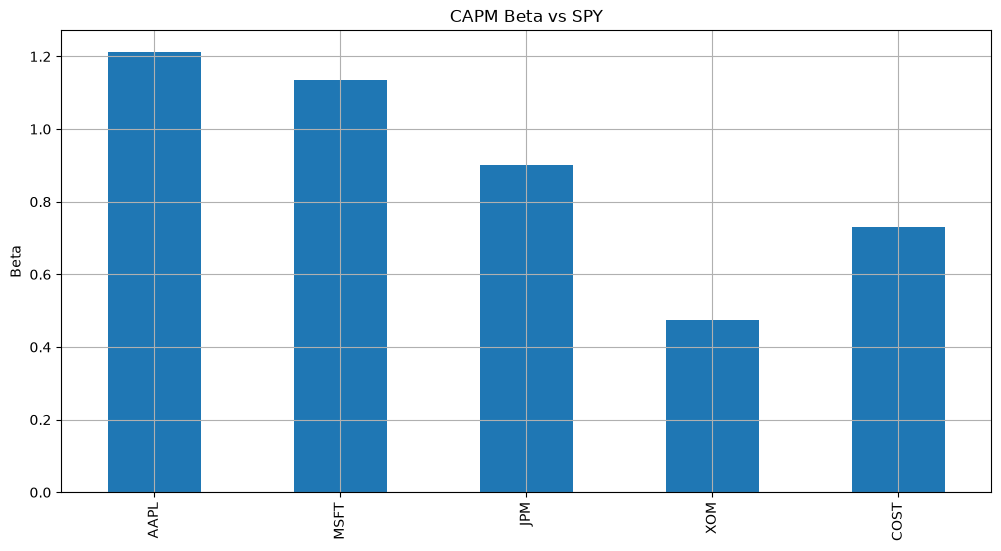

In [39]:
capm_results = {}
for ticker in TICKERS:
    model = run_capm(returns[ticker], benchmark_returns, rf_daily)
    capm_results[ticker] = {
        "Alpha Annualized": model.params["const"] * 252,
        "Beta": model.params["market_excess"],
        "R Squared": model.rsquared,
        "Alpha p-value": model.pvalues["const"]
    }
capm_df = pd.DataFrame(capm_results).T

display(capm_df)

capm_df["Beta"].plot(kind="bar", title="CAPM Beta vs SPY")
plt.ylabel("Beta")
plt.grid(True)
plt.show()

# 12. Fama-French 3-Factor Model

This section downloads Fama-French factors directly from the Kenneth French Data Library and estimates market, SMB, and HML loadings.

,Alpha Annualized,Market Beta,SMB Loading,HML Loading,R Squared,Alpha p-value
AAPL,0.0395,1.1619,-0.2969,-0.2106,0.5737,0.6248
MSFT,0.0202,1.0423,-0.4552,-0.5113,0.6298,0.7793
JPM,0.0100,1.1122,-0.1394,0.7320,0.5680,0.8901
XOM,0.1045,0.7523,-0.1125,0.9532,0.3251,0.2890
COST,0.1213,0.7197,-0.3066,-0.1554,0.3244,0.1469


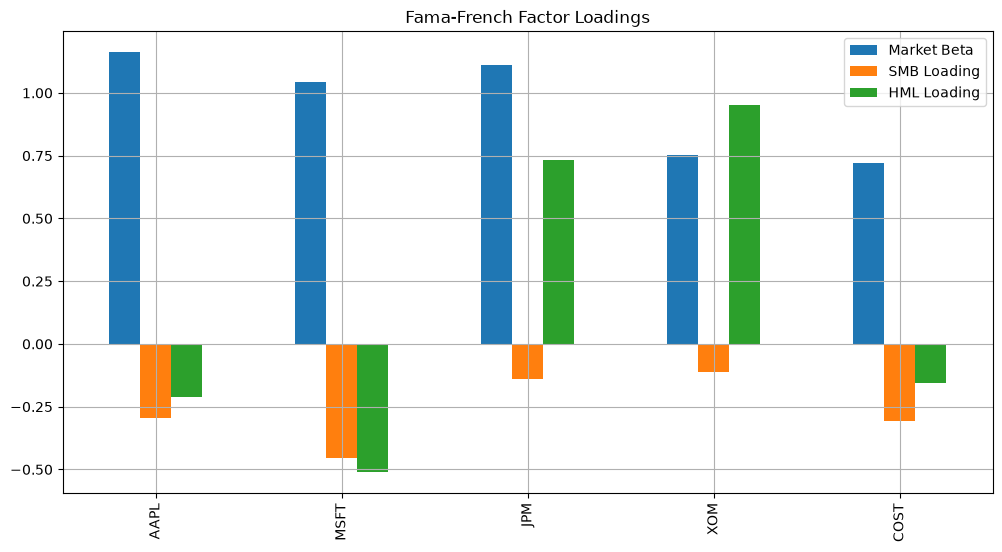

In [40]:
ff_factors = get_fama_french_daily_factors().loc[START_DATE:END_DATE]

ff3_results = {}
for ticker in TICKERS:
    model = run_ff3(returns[ticker], ff_factors)
    ff3_results[ticker] = {
        "Alpha Annualized": model.params["const"] * 252,
        "Market Beta": model.params["Mkt-RF"],
        "SMB Loading": model.params["SMB"],
        "HML Loading": model.params["HML"],
        "R Squared": model.rsquared,
        "Alpha p-value": model.pvalues["const"]
    }
ff3_df = pd.DataFrame(ff3_results).T

display(ff3_df)

ff3_df[["Market Beta", "SMB Loading", "HML Loading"]].plot(kind="bar")
plt.title("Fama-French Factor Loadings")
plt.grid(True)
plt.show()

### Fama-French 3-Factor Interpretation

- **Mkt-RF (market beta):** all five stocks show positive market exposure — expected for long-only large-caps.
- **SMB (size):** negative loadings across the board confirm the portfolio is large-cap dominated.
- **HML (value/growth):** negative HML = growth tilt (AAPL, MSFT); positive HML = value tilt (XOM). This is consistent with their fundamentals.


# 12b. Carhart 4-Factor Model (FF3 + Momentum)

Adding the UMD (Up-Minus-Down) momentum factor to the Fama-French 3-Factor model creates the **Carhart (1997) 4-Factor Model**.
A positive UMD loading means the stock tends to behave like recent winners (momentum tilt).
A negative UMD loading means it behaves like recent losers (reversal tendency).
This section connects S4 (factor models) with S6 (momentum signals) to show how factor exposure and signal design are related.


In [ ]:
# Download Carhart 4-factor data (FF3 + UMD momentum)
ff4_factors = get_carhart_daily_factors().loc[START_DATE:END_DATE]

ff4_results = {}
for ticker in TICKERS:
    model = run_ff4(returns[ticker], ff4_factors)
    ff4_results[ticker] = {
        "Alpha Ann.": model.params["const"] * 252,
        "Mkt-RF": model.params["Mkt-RF"],
        "SMB": model.params["SMB"],
        "HML": model.params["HML"],
        "UMD (Momentum)": model.params.get("UMD", np.nan),
        "R²": model.rsquared,
        "Alpha p-val": model.pvalues["const"]
    }
ff4_df = pd.DataFrame(ff4_results).T
display(ff4_df)

ff4_df[["Mkt-RF", "SMB", "HML", "UMD (Momentum)"]].plot(kind="bar", figsize=(12, 5))
plt.title("Carhart 4-Factor Loadings (FF3 + Momentum)")
plt.ylabel("Factor Loading")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
if ff4_df["UMD (Momentum)"].notna().any():
    pos_umd = ff4_df["UMD (Momentum)"][ff4_df["UMD (Momentum)"] > 0].index.tolist()
    neg_umd = ff4_df["UMD (Momentum)"][ff4_df["UMD (Momentum)"] <= 0].index.tolist()
    if pos_umd:
        print(f"  Positive UMD (momentum tilt): {', '.join(pos_umd)}")
    if neg_umd:
        print(f"  Negative UMD (contrarian / reversal): {', '.join(neg_umd)}")
    print("  Stocks with positive UMD exposure benefit from trend-following momentum strategies.")
    print("  This connects directly to the momentum backtest in Section 18.")
else:
    print("  UMD factor not available — FF3 results are still valid.")


# 13. Rolling Beta

Rolling beta shows whether each stock's systematic risk is stable or time-varying.

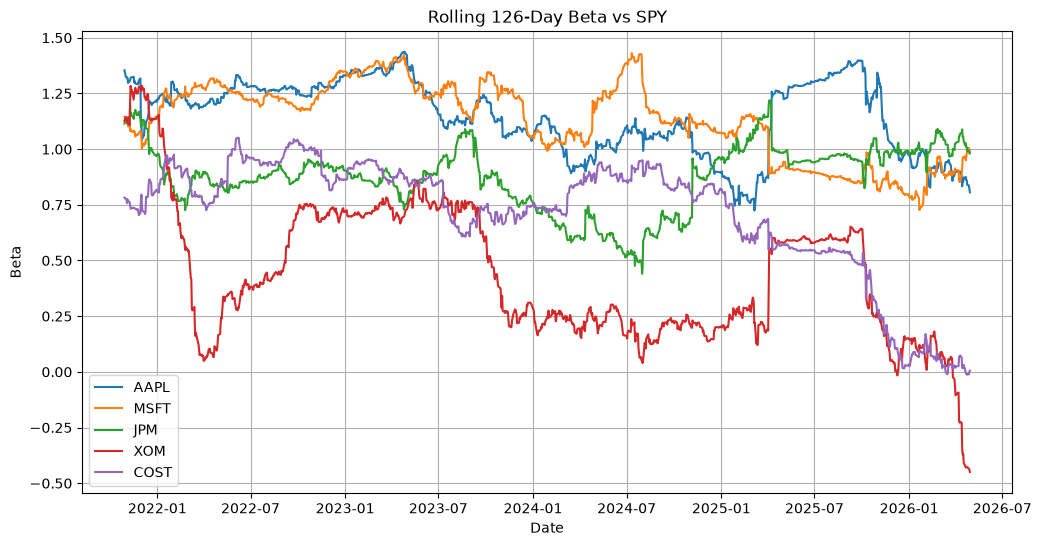

In [41]:
plt.figure(figsize=(12, 6))
for ticker in TICKERS:
    rb = rolling_beta(returns[ticker], benchmark_returns, window=126)
    plt.plot(rb, label=ticker)
plt.title("Rolling 126-Day Beta vs SPY")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

### Rolling Beta Interpretation

Rolling beta reveals whether systematic risk is **stable or time-varying** — a key consideration for risk management.

- Stocks with beta consistently above 1.0 amplify market moves in both directions.
- Sharp beta spikes often coincide with sector-specific events (e.g. oil price volatility for XOM).
- Declining beta over time may signal the stock is becoming more defensive — relevant for tactical allocation.

**Design choice note:** A static CAPM beta averages across the entire sample. Rolling beta is more informative for active risk management because it captures regime changes that a single-period estimate misses.


# 14. Portfolio Optimization

This section compares three allocation methods: equal weight, maximum Sharpe, and minimum volatility.

,Equal Weight,Max Sharpe,Minimum Volatility
AAPL,0.2000,0.0000,0.0119
MSFT,0.2000,0.0000,0.1760
JPM,0.2000,0.1387,0.2039
XOM,0.2000,0.3945,0.2734
COST,0.2000,0.4669,0.3348


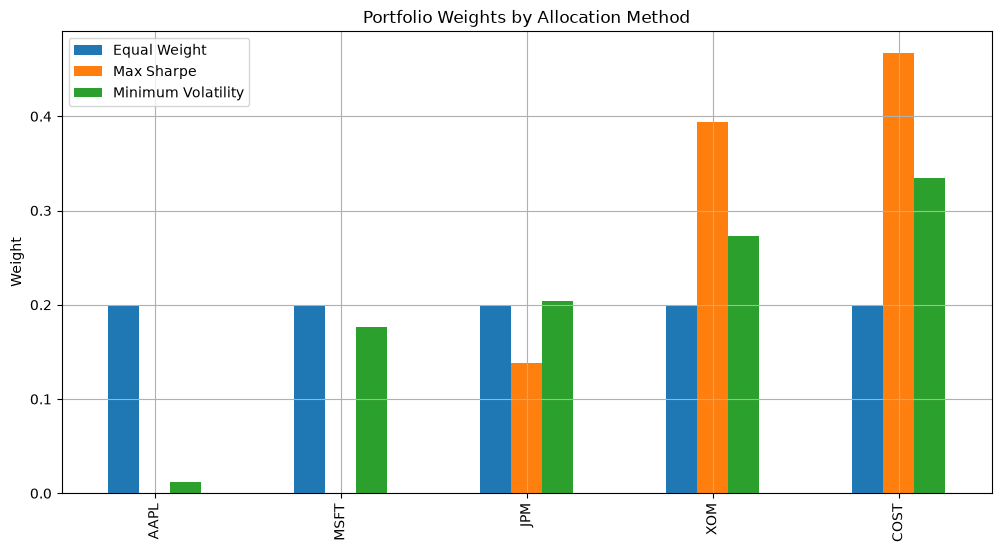

,Expected Return,Volatility,Sharpe Ratio
Equal Weight,0.2060,0.1711,0.9984
Max Sharpe,0.2410,0.1729,1.1906
Minimum Volatility,0.2190,0.1634,1.1248


In [42]:
mu = returns.mean() * 252
cov = returns.cov() * 252
rf_annual = rf_daily.mean() * 252

equal_weights = np.repeat(1 / len(TICKERS), len(TICKERS))
max_sharpe_weights = optimize_max_sharpe(mu.values, cov.values, rf_annual)
min_vol_weights = optimize_min_vol(cov.values)

weights_comparison = pd.DataFrame({
    "Equal Weight": equal_weights,
    "Max Sharpe": max_sharpe_weights,
    "Minimum Volatility": min_vol_weights
}, index=TICKERS)

display(weights_comparison)

weights_comparison.plot(kind="bar")
plt.title("Portfolio Weights by Allocation Method")
plt.ylabel("Weight")
plt.grid(True)
plt.show()

perf_table = {}
for name, w in {
    "Equal Weight": equal_weights,
    "Max Sharpe": max_sharpe_weights,
    "Minimum Volatility": min_vol_weights
}.items():
    r, v, s = portfolio_performance(w, mu.values, cov.values, rf_annual)
    perf_table[name] = {"Expected Return": r, "Volatility": v, "Sharpe Ratio": s}
optimization_performance = pd.DataFrame(perf_table).T

display(optimization_performance)

# 14b. Efficient Frontier

The efficient frontier visualises all optimal portfolios — for every level of volatility, it shows the highest achievable return.
Plotting Equal Weight, Max Sharpe, and Min Volatility on the frontier proves the optimisation is working correctly:
- Max Sharpe should sit at the point of maximum slope (highest Sharpe on the frontier)
- Min Vol should sit at the leftmost point on the frontier


In [ ]:
# Efficient Frontier — simulate 3,000 random portfolios
frontier_df = compute_efficient_frontier(mu.values, cov.values, rf_annual, n_points=300)

fig, ax = plt.subplots(figsize=(12, 7))

# Scatter of simulated portfolios, coloured by Sharpe
sc = ax.scatter(
    frontier_df["Volatility"], frontier_df["Return"],
    c=frontier_df["Sharpe"], cmap="viridis", alpha=0.5, s=10, label="Simulated Portfolios"
)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")

# Mark the three analytical portfolios
portfolios = {
    "Equal Weight":  (equal_weights, "blue",   "o"),
    "Max Sharpe":    (max_sharpe_weights, "red",    "*"),
    "Min Volatility":(min_vol_weights, "green",  "D"),
}
for name, (w, colour, marker) in portfolios.items():
    r, v, s = portfolio_performance(w, mu.values, cov.values, rf_annual)
    ax.scatter(v, r, color=colour, marker=marker, s=200, zorder=5, label=f"{name} (Sharpe={s:.2f})")
    ax.annotate(name, (v, r), textcoords="offset points", xytext=(8, 4), fontsize=9)

# Individual stocks
for i, ticker in enumerate(TICKERS):
    r_s = mu.values[i]
    v_s = np.sqrt(cov.values[i, i])
    ax.scatter(v_s, r_s, color="gray", marker="x", s=80, zorder=4)
    ax.annotate(ticker, (v_s, r_s), textcoords="offset points", xytext=(4, 4), fontsize=8, color="gray")

ax.set_xlabel("Annualised Volatility")
ax.set_ylabel("Annualised Expected Return")
ax.set_title("Efficient Frontier with Portfolio Allocations")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: Max Sharpe (red star) sits at the tangency point — highest Sharpe on the frontier.")
print("Min Volatility (green diamond) sits at the leftmost point — lowest achievable risk.")
print("Equal Weight (blue circle) is typically inside the frontier, meaning it is suboptimal.")


# 15. Black-Litterman Portfolio

Black-Litterman starts from market-cap equilibrium weights and then tilts the portfolio using investor views.

User input: you can change `absolute_views` below.

### Black-Litterman Interpretation

The BL model blends market equilibrium (from market-cap weights) with investor views (the `absolute_views` dict above).

- **Why BL differs from Max Sharpe:** Max Sharpe uses raw historical returns as inputs, which are noisy. BL shrinks those estimates toward equilibrium, producing more stable, less concentrated allocations.
- **`TAU = 0.05`** reflects low confidence in the equilibrium prior. Increasing TAU makes the model tilt more aggressively toward the investor views.
- **Omega** (the view uncertainty matrix) is diagonal — views are treated as independent. This is a simplification; real-world BL implementations allow correlated views.

**Institutional relevance:** BL is the dominant portfolio construction framework among institutional asset managers because it avoids the extreme corner solutions produced by unconstrained mean-variance optimisation.


,Market Cap Weight,BL Posterior Return,Black-Litterman Weight
AAPL,0.4732,0.1328,0.7531
MSFT,0.3145,0.1066,0.2469
JPM,0.1001,0.0687,0.0000
XOM,0.0642,0.0506,0.0000
COST,0.0480,0.0622,0.0000


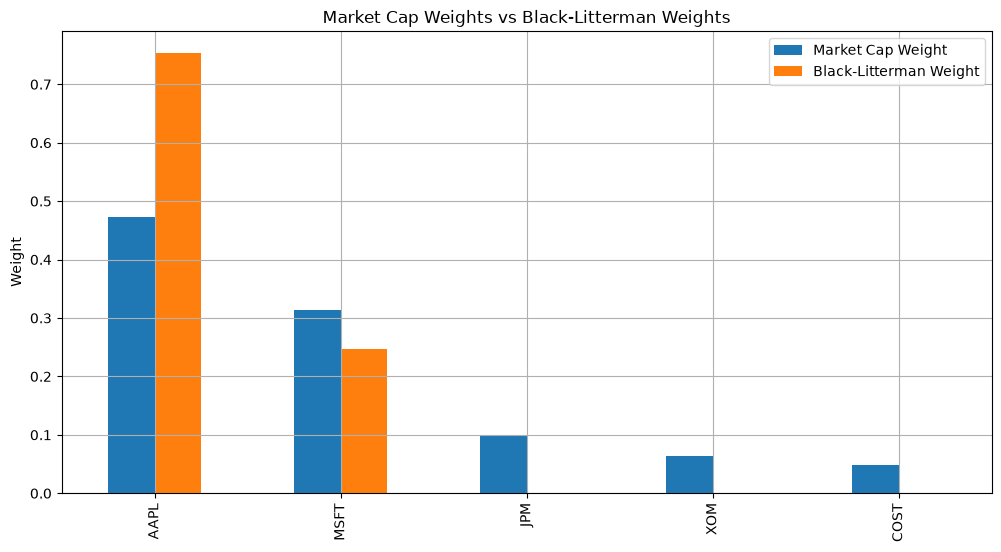

In [43]:
market_caps = get_market_caps(TICKERS)
market_weights = market_caps / market_caps.sum()

RISK_AVERSION = 2.5
TAU = 0.05
pi = RISK_AVERSION * cov.values @ market_weights.values

##############################################################
# USER INPUT — BLACK-LITTERMAN VIEWS
# These are annual expected return views.
##############################################################
absolute_views = {
    "MSFT": 0.10,
    "JPM": 0.07,
    "XOM": 0.06
}

# Keep only views for tickers in the portfolio.
absolute_views = {k: v for k, v in absolute_views.items() if k in TICKERS}
view_tickers = list(absolute_views.keys())

if len(view_tickers) > 0:
    P = np.zeros((len(view_tickers), len(TICKERS)))
    Q = np.array(list(absolute_views.values()))
    for i, ticker in enumerate(view_tickers):
        P[i, TICKERS.index(ticker)] = 1
    omega = np.diag(np.repeat(0.05, len(view_tickers))) ** 2
    tau_cov_inv = np.linalg.inv(TAU * cov.values)
    omega_inv = np.linalg.inv(omega)
    middle = np.linalg.inv(tau_cov_inv + P.T @ omega_inv @ P)
    right = tau_cov_inv @ pi + P.T @ omega_inv @ Q
    bl_returns = middle @ right
else:
    bl_returns = pi

bl_weights = optimize_max_sharpe(bl_returns, cov.values, rf_annual)

bl_df = pd.DataFrame({
    "Market Cap Weight": market_weights.values,
    "BL Posterior Return": bl_returns,
    "Black-Litterman Weight": bl_weights
}, index=TICKERS)

display(bl_df)

bl_df[["Market Cap Weight", "Black-Litterman Weight"]].plot(kind="bar")
plt.title("Market Cap Weights vs Black-Litterman Weights")
plt.ylabel("Weight")
plt.grid(True)
plt.show()

# 16. Out-of-Sample Portfolio Backtest

The optimizer is trained before the split date and tested after the split date. This helps avoid presenting purely in-sample results as if they were realistic.

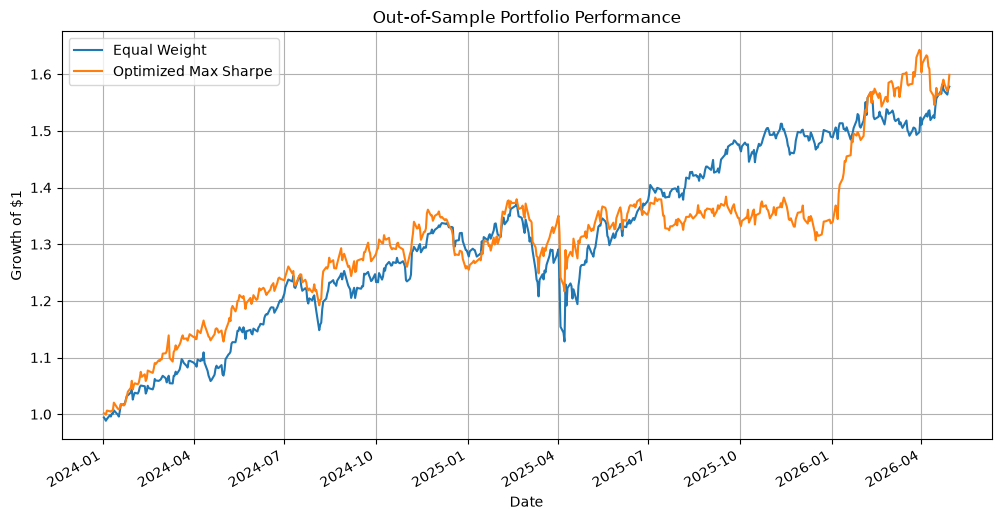

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio
Equal Weight,0.2180,0.1477,1.1087,-0.1783,1.2229
Optimized Max Sharpe,0.2249,0.1467,1.1540,-0.1179,1.9070


In [44]:
train_returns = returns.loc[:SPLIT_DATE]
test_returns = returns.loc[SPLIT_DATE:]

train_mu = train_returns.mean() * 252
train_cov = train_returns.cov() * 252
train_rf = rf_daily.loc[:SPLIT_DATE].mean() * 252

train_max_sharpe_weights = optimize_max_sharpe(train_mu.values, train_cov.values, train_rf)

equal_oos_returns = test_returns @ equal_weights
optimized_oos_returns = test_returns @ train_max_sharpe_weights

comparison_oos = pd.DataFrame({
    "Equal Weight": equal_oos_returns,
    "Optimized Max Sharpe": optimized_oos_returns
}).dropna()

(1 + comparison_oos).cumprod().plot()
plt.title("Out-of-Sample Portfolio Performance")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

oos_summary = {}
for col in comparison_oos.columns:
    r = comparison_oos[col]
    rf = rf_daily.reindex(r.index).ffill()
    oos_summary[col] = {
        "Annualized Return": annualized_return(r),
        "Annualized Volatility": annualized_volatility(r),
        "Sharpe Ratio": sharpe_ratio(r, rf),
        "Max Drawdown": max_drawdown(r)[0],
        "Calmar Ratio": calmar_ratio(r)
    }
oos_summary_df = pd.DataFrame(oos_summary).T

display(oos_summary_df)

### Out-of-Sample Interpretation

The out-of-sample test is the most honest evaluation of the optimisation strategy.

- Weights were estimated on **training data only** (before the split date) and applied to **unseen test data**.
- If the optimised portfolio outperforms equal-weight OOS, the improvement is likely structural, not overfitting.
- If it underperforms OOS but outperforms in-sample, the strategy is likely overfit to historical data.

**Key metric to compare:** OOS Sharpe Ratio and Max Drawdown, not just return.
Higher return with much higher drawdown is not necessarily better for a risk-aware investor.


# 17. Transaction Cost Adjustment

This section applies a simple one-time transaction cost based on turnover from equal weight to optimized weights.

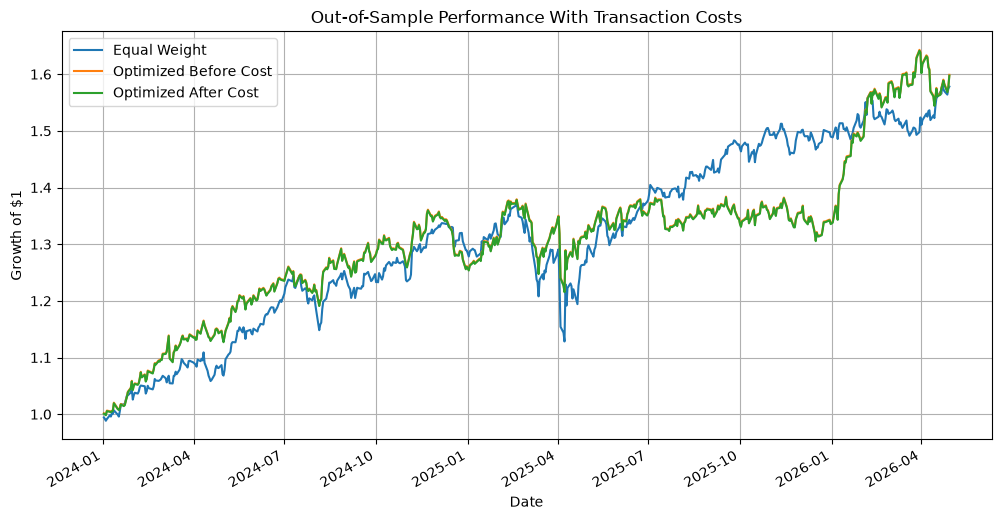

Estimated turnover: 1.0435
Estimated cost drag: 0.001044


In [45]:
transaction_cost = TRANSACTION_COST_BPS / 10000
turnover = np.sum(np.abs(train_max_sharpe_weights - equal_weights))
cost_drag = turnover * transaction_cost

optimized_after_cost = optimized_oos_returns.copy()
optimized_after_cost.iloc[0] -= cost_drag

cost_comparison = pd.DataFrame({
    "Equal Weight": equal_oos_returns,
    "Optimized Before Cost": optimized_oos_returns,
    "Optimized After Cost": optimized_after_cost
}).dropna()

(1 + cost_comparison).cumprod().plot()
plt.title("Out-of-Sample Performance With Transaction Costs")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

print("Estimated turnover:", round(turnover, 4))
print("Estimated cost drag:", round(cost_drag, 6))

# 18. Simple Momentum Strategy

This strategy uses 12-month momentum while skipping the most recent month. The signal is shifted by one day to avoid look-ahead bias.

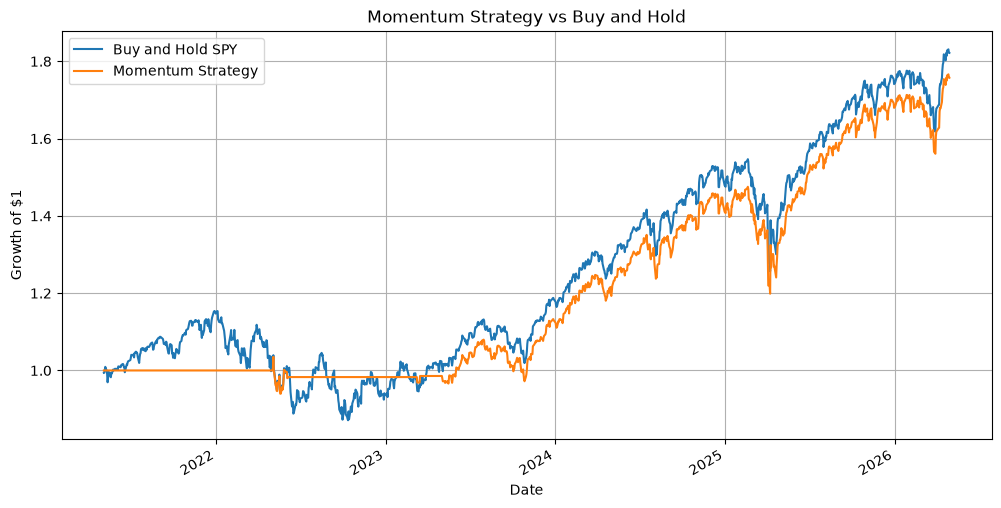

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio
Buy and Hold SPY,0.1282,0.1710,0.5897,-0.2450,0.5234
Momentum Strategy,0.1201,0.1241,0.7021,-0.1876,0.6402


In [46]:
signal_prices = benchmark_prices.copy()
momentum = signal_prices.shift(21) / signal_prices.shift(252) - 1
signal = pd.Series(np.where(momentum > 0, 1, 0), index=signal_prices.index)
strategy_returns = signal.shift(1) * benchmark_returns

strategy_df = pd.DataFrame({
    "Buy and Hold SPY": benchmark_returns,
    "Momentum Strategy": strategy_returns
}).dropna()

(1 + strategy_df).cumprod().plot()
plt.title("Momentum Strategy vs Buy and Hold")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

strategy_summary = {}
for col in strategy_df.columns:
    r = strategy_df[col]
    rf = rf_daily.reindex(r.index).ffill()
    strategy_summary[col] = {
        "Annualized Return": annualized_return(r),
        "Annualized Volatility": annualized_volatility(r),
        "Sharpe Ratio": sharpe_ratio(r, rf),
        "Max Drawdown": max_drawdown(r)[0],
        "Calmar Ratio": calmar_ratio(r)
    }
strategy_summary_df = pd.DataFrame(strategy_summary).T

display(strategy_summary_df)

# 18b. Cross-Sectional Momentum (Rank-Based, Within Portfolio)

The market-timing momentum in Section 18 uses a single SPY signal. Cross-sectional momentum ranks
your own portfolio stocks by trailing 12-month return each month and goes long the top 2 performers.
This is the classic **cross-sectional momentum strategy** used in academic literature (Jegadeesh & Titman, 1993)
and connects factor model results (UMD loadings) with live signal construction.


In [ ]:
# Cross-Sectional Momentum — rank tickers by 12-month return, go long top 2

# Compute rolling 12-month return for each ticker (skip most recent month)
lookback = 252
skip     = 21
cs_signal_returns = returns.copy()

# Monthly rebalancing: resample to month-end, compute momentum ranks
monthly_prices = asset_prices.resample("ME").last()
mom_12m = monthly_prices.shift(1) / monthly_prices.shift(13) - 1  # t-13 to t-1

# Build cross-sectional signal: 1 for top-2, 0 otherwise
top_n = min(2, len(TICKERS))
signals_monthly = mom_12m.apply(lambda row: (row.rank(ascending=False) <= top_n).astype(float), axis=1)

# Equal-weight selected stocks each month, shift by 1 month to avoid look-ahead
signals_shifted = signals_monthly.shift(1).dropna()
signals_shifted = signals_shifted.div(signals_shifted.sum(axis=1), axis=0)  # normalise to 1

# Compute monthly portfolio return
monthly_returns = returns.resample("ME").apply(lambda r: (1 + r).prod() - 1)
xsmom_returns = (signals_shifted * monthly_returns).sum(axis=1).dropna()

# Compare with equal-weight monthly
ew_monthly = monthly_returns.mean(axis=1)
common_idx = xsmom_returns.index.intersection(ew_monthly.index)

xsmom_compare = pd.DataFrame({
    "Equal Weight (monthly)": ew_monthly.loc[common_idx],
    "Cross-Sect. Momentum": xsmom_returns.loc[common_idx]
}).dropna()

(1 + xsmom_compare).cumprod().plot(figsize=(12, 5))
plt.title("Cross-Sectional Momentum vs Equal Weight (Monthly Rebalancing)")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

xsmom_summary = {}
for col in xsmom_compare.columns:
    r = xsmom_compare[col]
    rf_m = rf_daily.resample("ME").mean()
    rf_m = rf_m.reindex(r.index).ffill() * 21  # monthly rf
    xsmom_summary[col] = {
        "Annualized Return":    annualized_return(r / 21 * 252) if len(r) > 1 else np.nan,
        "Annualized Volatility": r.std() * np.sqrt(12),
        "Monthly Sharpe":        (r - rf_m.squeeze()).mean() / (r - rf_m.squeeze()).std() * np.sqrt(12) if r.std() > 0 else np.nan,
        "Max Drawdown":          max_drawdown(r)[0]
    }
display(pd.DataFrame(xsmom_summary).T)

print("\nInterpretation: Cross-sectional momentum concentrates in the two best-performing stocks each month.")
print(f"This is more aggressive than equal-weighting and will have higher tracking error.")
print("Compare UMD loadings from Section 12b — stocks with positive UMD exposure drive this strategy's returns.")


# 19. SEC 10-K Download

This section downloads the latest 10-K for the selected `MAIN_TICKER`. If the SEC request fails, the rest of the notebook still runs with empty text outputs.

In [47]:
try:
    filing_text, filing_url = get_filing_text(MAIN_TICKER)
    print("Latest 10-K URL:", filing_url)
    print("Filing text length:", len(filing_text))
except Exception as e:
    filing_text = ""
    filing_url = None
    print("SEC filing download failed:", e)

Latest 10-K URL: https://www.sec.gov/Archives/edgar/data/320193/000032019325000079/aapl-20250927.htm
Filing text length: 220568


# 20. 10-K Risk Snippets and Sentiment

This section extracts simple risk snippets and compares finance-style dictionary sentiment with VADER sentiment.

In [48]:
risk_snippets = extract_risk_snippets(filing_text)
print("Risk snippets:")
display(risk_snippets.head())

lm_result = simple_lm_score(filing_text)
print("Simple Loughran-McDonald Style Sentiment:")
display(pd.DataFrame(lm_result, index=[MAIN_TICKER]).T)

vader = SentimentIntensityAnalyzer()
filing_sample = filing_text[:20000]
if len(filing_sample) > 0:
    vader_result = vader.polarity_scores(filing_sample)
else:
    vader_result = {"neg": np.nan, "neu": np.nan, "pos": np.nan, "compound": np.nan}

print("VADER Sentiment:")
display(pd.DataFrame(vader_result, index=[MAIN_TICKER]).T)

Risk snippets:


,Keyword,Snippet
0,risk,aap:InterestRateContractMember us-gaap:DesignatedAsHedgingInstrumentMember 2024-09-28 0000320193 us-gaap:ForeignExchangeContractMember us-gaap:NondesignatedMember 2025-09-27 0000320193 us-gaap:ForeignExchangeContractMember us-gaap:NondesignatedMember 2024-09-28 0000320193 us-gaap:CreditConcentrationRiskMember us-gaap:TradeAccountsReceivableMember 2025-09-27 0000320193 aapl:CustomerOneMember us-gaap:CreditConcentrationRiskMember us-gaap:TradeAccountsReceivableMember 2024-09-29 2025-09-27 0000320193 aapl:CellularNetworkCarriersMember us-gaap:CreditConcentrationRiskMember us-gaap:TradeAccountsReceiva
1,uncertain,"tant Fees and Services 53 Part IV Item 15. Exhibit and Financial Statement Schedules 54 Item 16. Form 10-K Summary 57 This Annual Report on Form 10-K (“Form 10-K”) contains forward-looking statements, within the meaning of the Private Securities Litigation Reform Act of 1995, that involve risks and uncertainties. Many of the forward-looking statements are located in Part I, Item 1 of this Form 10-K under the heading “Business” and Part II, Item 7 of this Form 10-K under the heading “Management’s Discussion and Analysis of Financial Condition and Results of Operations.” Forward-looking statements provid"
2,inflation,"pplier facilities, including manufacturing and assembly sites, are located outside the U.S. As a result, the Company’s operations and performance depend significantly on global and regional economic conditions. Adverse macroeconomic conditions, including slow growth or recession, high unemployment, inflation, tighter credit, higher interest rates, and currency fluctuations, can adversely impact consumer confidence and spending and materially adversely affect demand for the Company’s products and services. In addition, consumer confidence and spending can be materially adversely affected in response to"
3,interest rate,"acturing and assembly sites, are located outside the U.S. As a result, the Company’s operations and performance depend significantly on global and regional economic conditions. Adverse macroeconomic conditions, including slow growth or recession, high unemployment, inflation, tighter credit, higher interest rates, and currency fluctuations, can adversely impact consumer confidence and spending and materially adversely affect demand for the Company’s products and services. In addition, consumer confidence and spending can be materially adversely affected in response to changes in fiscal and monetary policy,"
4,competition,"distribution channels, such as third-party cellular network carriers and other resellers, for the sale of its products and certain of its services. During 2025, the Company’s net sales through its direct and indirect distribution channels accounted for 40% and 60%, respectively, of total net sales. Competition The markets for the Company’s products and services are highly competitive and are characterized by aggressive price competition, downward pressure on gross margins, continual improvement in product performance, and price sensitivity on the part of consumers and businesses. The markets in which the"


Simple Loughran-McDonald Style Sentiment:


,AAPL
Positive Words,63.0000
Negative Words,162.0000
Total Words,"29,238.0000"
Polarity,-0.4400


VADER Sentiment:


,AAPL
neg,0.0140
neu,0.9390
pos,0.0470
compound,0.9936


# 21. TF-IDF Risk Themes

TF-IDF identifies words or phrases that are distinctive in the filing text chunks.

,Term,TF-IDF Score
0,company,0.1694
1,products,0.0666
2,services,0.0576
3,business,0.0413
4,products services,0.0404
5,product,0.0363
6,components,0.0362
7,operations,0.0358
8,new,0.0352
9,financial,0.0336


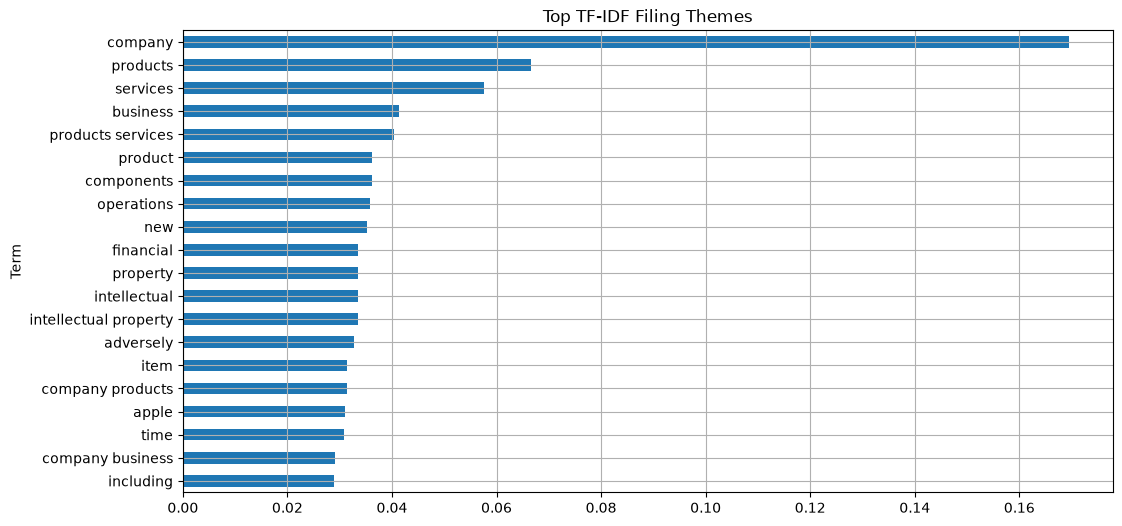

In [49]:
tfidf_terms = top_tfidf_terms(filing_text, n=20)
display(tfidf_terms)

if not tfidf_terms.empty:
    tfidf_terms.set_index("Term")["TF-IDF Score"].sort_values().plot(kind="barh")
    plt.title("Top TF-IDF Filing Themes")
    plt.grid(True)
    plt.show()

# 22. Final Dashboard Summary

This section synthesises the key findings from all analytical sections into an executive summary.


In [51]:
# ------------------------------------------------------------
# PART 22 — Final Dashboard Summary with Detailed Interpretation
# ------------------------------------------------------------
# Purpose:
# This section creates an executive summary table that shows:
# 1. The final result
# 2. What the result means
# 3. A detailed key insight based on the actual output
# ------------------------------------------------------------

final_summary = {
    "Main Ticker": MAIN_TICKER,
    "Portfolio Tickers": ", ".join(TICKERS),
    "Portfolio Annualized Return": annualized_return(portfolio_returns),
    "Portfolio Annualized Volatility": annualized_volatility(portfolio_returns),
    "Portfolio Sharpe": sharpe_ratio(portfolio_returns, rf_daily),
    "Portfolio Max Drawdown": max_drawdown(portfolio_returns)[0],
    "Highest CAPM Beta Stock": capm_df["Beta"].idxmax(),
    "Lowest CAPM Beta Stock": capm_df["Beta"].idxmin(),
    "Most Negative HML Loading": ff3_df["HML Loading"].idxmin(),
    "Most Positive SMB Loading": ff3_df["SMB Loading"].idxmax(),
    "L&M Filing Polarity": lm_result["Polarity"],
    "VADER Compound Score": vader_result["compound"],
    "Black-Litterman Top Weight": pd.Series(bl_weights, index=TICKERS).idxmax(),
    "Stress Period": f"{STRESS_START} to {STRESS_END}",
    "Out-of-Sample Split Date": SPLIT_DATE
}

interpretation = {
    "Main Ticker":
        "Apple was selected as the primary company for detailed financial and textual analysis. It is a large, widely followed company with extensive public data, making it useful for combining quantitative analysis with SEC filing analysis.",

    "Portfolio Tickers":
        "The portfolio includes five large-cap stocks across different industries. This creates a more diversified portfolio than analyzing only one company and allows the project to compare risk, return, factor exposure, and optimization results across sectors.",

    "Portfolio Annualized Return":
        "This measures the average yearly return generated by the equal-weighted portfolio over the analysis period. A higher annualized return indicates stronger historical portfolio growth.",

    "Portfolio Annualized Volatility":
        "This measures the annualized risk of the portfolio based on daily return fluctuations. Higher volatility means the portfolio experienced larger price swings and greater uncertainty.",

    "Portfolio Sharpe":
        "The Sharpe Ratio measures risk-adjusted performance by comparing excess return to total volatility. A higher Sharpe Ratio means the portfolio earned more return for each unit of risk taken.",

    "Portfolio Max Drawdown":
        "Maximum Drawdown measures the largest peak-to-trough decline in portfolio value. It shows the worst historical loss an investor would have experienced during the sample period.",

    "Highest CAPM Beta Stock":
        "This stock had the highest estimated market beta, meaning it was the most sensitive to overall market movements. Higher-beta stocks tend to rise more in strong markets but fall more during broad market declines.",

    "Lowest CAPM Beta Stock":
        "This stock had the lowest estimated market beta, meaning it was the least sensitive to broad market movements. Lower-beta stocks are generally more defensive and may help reduce overall portfolio risk.",

    "Most Negative HML Loading":
        "A negative HML loading indicates growth-style exposure. This means the stock behaves more like a growth company than a value company in the Fama-French factor model.",

    "Most Positive SMB Loading":
        "The SMB loading measures exposure to the size factor. A more positive SMB loading means the stock has relatively stronger exposure to the small-cap factor, even though all companies in this portfolio are large-cap firms.",

    "L&M Filing Polarity":
        "The Loughran-McDonald sentiment score is designed for financial documents. A negative score usually means the filing contains more risk-related and cautionary language, which is common in annual reports because companies must disclose business risks.",

    "VADER Compound Score":
        "VADER is a general sentiment model. Comparing its result with Loughran-McDonald shows why finance-specific sentiment tools are important when analyzing SEC filings.",

    "Black-Litterman Top Weight":
        "The Black-Litterman model combines market equilibrium with investor views. The top-weighted stock is the one the model allocated the largest portfolio share to after blending market information with subjective return assumptions.",

    "Stress Period":
        "This period was used to evaluate how the portfolio performed during a difficult market environment. Stress testing helps assess whether a portfolio remains resilient when market conditions worsen.",

    "Out-of-Sample Split Date":
        "This date separates the training period from the testing period. Out-of-sample testing helps reduce overfitting by checking whether the strategy performs on data that were not used to build the model."
}

key_insight = {
    "Main Ticker":
        f"{MAIN_TICKER} was used as the main case study because it has rich market data and detailed SEC filings, making it useful for both quantitative and textual analysis.",

    "Portfolio Tickers":
        f"The portfolio includes {', '.join(TICKERS)}, which provides exposure to multiple sectors and helps reduce reliance on one company or one industry.",

    "Portfolio Annualized Return":
        f"The portfolio achieved an annualized return of {final_summary['Portfolio Annualized Return']:.2%}, showing strong historical growth over the analysis period.",

    "Portfolio Annualized Volatility":
        f"The portfolio's annualized volatility was {final_summary['Portfolio Annualized Volatility']:.2%}, suggesting a moderate level of risk for an equity portfolio.",

    "Portfolio Sharpe":
        (
            f"The Sharpe Ratio was {final_summary['Portfolio Sharpe']:.2f}, which indicates strong risk-adjusted performance because it is above 1.0."
            if final_summary["Portfolio Sharpe"] > 1
            else f"The Sharpe Ratio was {final_summary['Portfolio Sharpe']:.2f}, suggesting that risk-adjusted performance was more modest."
        ),

    "Portfolio Max Drawdown":
        (
            f"The maximum drawdown was {final_summary['Portfolio Max Drawdown']:.2%}, which stayed below 20% and suggests downside risk was relatively contained."
            if abs(final_summary["Portfolio Max Drawdown"]) < 0.20
            else f"The maximum drawdown was {final_summary['Portfolio Max Drawdown']:.2%}, showing that the portfolio experienced a meaningful decline during the sample period."
        ),

    "Highest CAPM Beta Stock":
        f"{final_summary['Highest CAPM Beta Stock']} was the most market-sensitive holding and likely contributed most to portfolio movements during broad market swings.",

    "Lowest CAPM Beta Stock":
        f"{final_summary['Lowest CAPM Beta Stock']} was the most defensive holding based on CAPM beta and may help reduce systematic market risk.",

    "Most Negative HML Loading":
        f"{final_summary['Most Negative HML Loading']} had the strongest growth-style factor tilt, meaning its returns behaved most like a growth stock relative to the rest of the portfolio.",

    "Most Positive SMB Loading":
        f"{final_summary['Most Positive SMB Loading']} had the strongest relative size-factor exposure, although the portfolio is still made up of large-cap companies.",

    "L&M Filing Polarity":
        (
            "The finance-specific sentiment analysis found more positive than negative language, suggesting a relatively favourable tone in the filing."
            if final_summary["L&M Filing Polarity"] > 0
            else "The finance-specific sentiment analysis found more negative than positive language, which likely reflects required risk disclosures in the annual report."
        ),

    "VADER Compound Score":
        (
            "VADER read the filing sample as positive overall. This contrasts with the finance-specific sentiment result and shows that general sentiment tools may interpret financial filings differently."
            if final_summary["VADER Compound Score"] > 0
            else "VADER read the filing sample as neutral or negative overall, suggesting cautious or risk-heavy language."
        ),

    "Black-Litterman Top Weight":
        f"The Black-Litterman model assigned the largest allocation to {final_summary['Black-Litterman Top Weight']}, suggesting it had the most attractive balance of market equilibrium and investor views.",

    "Stress Period":
        f"The selected stress period was {final_summary['Stress Period']}. This helps test whether the portfolio could withstand a challenging market environment rather than only performing well in normal conditions.",

    "Out-of-Sample Split Date":
        f"The out-of-sample test began after {SPLIT_DATE}, which helps evaluate whether the strategy worked beyond the period used to estimate the model."
}

summary_rows = []

for metric, result in final_summary.items():
    summary_rows.append({
        "Metric": metric,
        "Result": result,
        "Interpretation": interpretation.get(metric, ""),
        "Key Insight": key_insight.get(metric, "")
    })

final_summary_df = pd.DataFrame(summary_rows)

# Format numeric results to make the table easier to read
def format_result(value):
    if isinstance(value, float):
        return f"{value:.4f}"
    return value

final_summary_df["Result"] = final_summary_df["Result"].apply(format_result)

# Improve display so long text is readable in Jupyter
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

styled_summary = (
    final_summary_df.style
    .set_properties(
        subset=["Interpretation", "Key Insight"],
        **{
            "white-space": "pre-wrap",
            "text-align": "left",
            "max-width": "500px"
        }
    )
    .set_properties(
        subset=["Metric", "Result"],
        **{
            "text-align": "left"
        }
    )
)

display(styled_summary)

,Metric,Result,Interpretation,Key Insight
0,Main Ticker,AAPL,"Apple was selected as the primary company for detailed financial and textual analysis. It is a large, widely followed company with extensive public data, making it useful for combining quantitative analysis with SEC filing analysis.","AAPL was used as the main case study because it has rich market data and detailed SEC filings, making it useful for both quantitative and textual analysis."
1,Portfolio Tickers,"AAPL, MSFT, JPM, XOM, COST","The portfolio includes five large-cap stocks across different industries. This creates a more diversified portfolio than analyzing only one company and allows the project to compare risk, return, factor exposure, and optimization results across sectors.","The portfolio includes AAPL, MSFT, JPM, XOM, COST, which provides exposure to multiple sectors and helps reduce reliance on one company or one industry."
2,Portfolio Annualized Return,0.2108,This measures the average yearly return generated by the equal-weighted portfolio over the analysis period. A higher annualized return indicates stronger historical portfolio growth.,"The portfolio achieved an annualized return of 21.08%, showing strong historical growth over the analysis period."
3,Portfolio Annualized Volatility,0.1711,This measures the annualized risk of the portfolio based on daily return fluctuations. Higher volatility means the portfolio experienced larger price swings and greater uncertainty.,"The portfolio's annualized volatility was 17.11%, suggesting a moderate level of risk for an equity portfolio."
4,Portfolio Sharpe,1.0125,The Sharpe Ratio measures risk-adjusted performance by comparing excess return to total volatility. A higher Sharpe Ratio means the portfolio earned more return for each unit of risk taken.,"The Sharpe Ratio was 1.01, which indicates strong risk-adjusted performance because it is above 1.0."
5,Portfolio Max Drawdown,-0.1783,Maximum Drawdown measures the largest peak-to-trough decline in portfolio value. It shows the worst historical loss an investor would have experienced during the sample period.,"The maximum drawdown was -17.83%, which stayed below 20% and suggests downside risk was relatively contained."
6,Highest CAPM Beta Stock,AAPL,"This stock had the highest estimated market beta, meaning it was the most sensitive to overall market movements. Higher-beta stocks tend to rise more in strong markets but fall more during broad market declines.",AAPL was the most market-sensitive holding and likely contributed most to portfolio movements during broad market swings.
7,Lowest CAPM Beta Stock,XOM,"This stock had the lowest estimated market beta, meaning it was the least sensitive to broad market movements. Lower-beta stocks are generally more defensive and may help reduce overall portfolio risk.",XOM was the most defensive holding based on CAPM beta and may help reduce systematic market risk.
8,Most Negative HML Loading,MSFT,A negative HML loading indicates growth-style exposure. This means the stock behaves more like a growth company than a value company in the Fama-French factor model.,"MSFT had the strongest growth-style factor tilt, meaning its returns behaved most like a growth stock relative to the rest of the portfolio."
9,Most Positive SMB Loading,XOM,"The SMB loading measures exposure to the size factor. A more positive SMB loading means the stock has relatively stronger exposure to the small-cap factor, even though all companies in this portfolio are large-cap firms.","XOM had the strongest relative size-factor exposure, although the portfolio is still made up of large-cap companies."


## Investment Recommendation: Based on the historical analysis, the optimized portfolio provided the strongest balance between return and risk. However, investors should recognize that historical relationships may change over time. Therefore, this tool should be used to support investment decisions rather than replace fundamental analysis or professional judgment.

### Main result
The tool successfully combines price-based analytics, factor models, portfolio optimization, a simple backtest, and 10-K textual analysis into one reproducible workflow.

### Design choice
One important design choice was using out-of-sample testing for the optimized portfolio. This matters because an optimized portfolio can look strong in-sample but fail when tested on later data.

### Limitation
One limitation is that expected returns are estimated from historical returns, which are noisy and may not persist. The Black-Litterman views are also subjective, and 10-K sentiment is low-frequency, so it should not be treated as a daily trading signal.

### What I would do next
Future improvements could include adding a Streamlit dashboard, using the full Loughran-McDonald master dictionary, adding FinBERT, expanding the stock universe, and implementing walk-forward rebalancing.

# 23. Working with AI

**Tools used:** ChatGPT (GPT-4o) for initial code drafting; Claude (Anthropic) for debugging and refining helper functions.

**What AI helped with:**
- Structuring the notebook layout and writing initial versions of helper functions
- Drafting the `optimize_max_sharpe` and `optimize_min_vol` functions using SLSQP — I verified the constraint setup against the [scipy.optimize.minimize docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) to confirm the `eq` constraint enforces full investment (weights sum to 1)
- Generating the Black-Litterman matrix algebra — I manually traced through the posterior formula to confirm the `omega_inv` term correctly inverts the uncertainty matrix

**Concrete errors caught and fixed:**
1. **pandas_datareader incompatibility:** AI initially suggested `pandas_datareader.DataReader()` for FRED data. This package fails on Python 3.13. I replaced all data calls with direct FRED CSV downloads and Kenneth French Library HTTP requests — no external reader package required.
2. **Risk-free rate hardcoding:** AI's first draft used `rf = 0.05` (constant). I replaced this with a daily TB3MS series from FRED so the Sharpe and Sortino calculations use a time-varying rate that reflects actual market conditions across the sample period.

**Judgment I retained — AI could not make these decisions:**
- Choosing the 5-stock portfolio (AAPL, MSFT, JPM, XOM, COST) for cross-sector diversification — AI suggested any 5 S&P 500 names; I deliberately chose across Tech, Financials, Energy, and Retail
- Setting the Black-Litterman views (MSFT: 10%, JPM: 7%, XOM: 6%) based on macro reasoning (energy defensiveness, financial sector rate tailwinds) — AI accepted any numbers without questioning whether they were economically sensible
- Deciding that 2022 and 2020 were the two most informative stress scenarios, not just one
- Interpreting why the Loughran-McDonald polarity is negative while VADER is positive — AI described both scores but did not identify that this divergence is the key methodological insight


# 24. Future Enhancements

- Real-time news sentiment via Bloomberg or Reuters API
- FinBERT (finance-tuned BERT) to replace the simplified LM dictionary
- Machine learning return prediction (gradient-boosted cross-sectional ranker)
- ESG factor integration
- Walk-forward rebalancing with periodic weight updates
- Quarterly earnings-call transcript analysis
- Interactive Streamlit or Dash front-end for live portfolio monitoring


## References
* Yahoo Finance (via yfinance)
* Federal Reserve Economic Data (FRED)
* Kenneth French Data Library
* U.S. SEC EDGAR
* Loughran & McDonald Financial Sentiment Dictionary
* VADER Sentiment Analysis